# NER Dataset Analysis and Cleaning

This notebook analyzes and cleans the annotated NER dataset to:
- Check label formations and patterns
- Analyze label distribution
- Identify potential overfitting issues
- Balance the dataset
- Provide tools for label deletion

## 1. Installation and Dependencies

In [53]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 2. Import Libraries and Setup Logging

In [1]:
import json
import logging
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Load Dataset

In [6]:
# Path to dataset
DATASET_PATH = Path('../data/dataset/full/o_dataset.json')

def load_dataset(path: Path) -> List[Dict]:
    """Load the annotated dataset."""
    logger.info(f"Loading dataset from {path}")
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    logger.info(f"Loaded {len(data)} samples")
    return data

dataset = load_dataset(DATASET_PATH)

2025-11-12 09:17:35,040 - INFO - Loading dataset from ../data/dataset/full/o_dataset.json
2025-11-12 09:17:35,095 - INFO - Loaded 2238 samples


## 4. Extract Annotations

In [7]:
def extract_annotations(dataset: List[Dict]) -> List[Dict]:
    """Extract all annotations from the dataset."""
    annotations = []
    
    for sample in dataset:
        sample_id = sample['id']
        sample_project = sample.get('data', []).get('repo', 'unknown')
        text = sample['data'].get('text', '')
        
        for annotation in sample.get('annotations', []):
            if annotation.get('was_cancelled', False):
                continue
                
            for result in annotation.get('result', []):
                if result.get('type') == 'labels':
                    value = result['value']
                    annotations.append({
                        'project': sample_project,
                        'sample_id': sample_id,
                        'text': value['text'],
                        'label': value['labels'][0],
                        'start': value['start'],
                        'end': value['end'],
                        'length': len(value['text']),
                        'source_text': text
                    })
    
    logger.info(f"Extracted {len(annotations)} annotations")
    return annotations

annotations = extract_annotations(dataset)
df_annotations = pd.DataFrame(annotations)

logger.info(f"Total annotations: {len(df_annotations)}")
logger.info(f"Unique labels: {df_annotations['label'].nunique()}")
df_annotations.head()

2025-11-12 09:17:37,207 - INFO - Extracted 2449 annotations
2025-11-12 09:17:37,214 - INFO - Total annotations: 2449
2025-11-12 09:17:37,215 - INFO - Unique labels: 11


,project,sample_id,text,label,start,end,length,source_text
0,455_Citation_File_Format,2712,CC-BY-4.0,LICENSE,25,34,9,SPDX-License-Identifier: CC-BY-4.0 -->\n\n:war...
1,455_Citation_File_Format,2713,MIT,LICENSE,1412,1415,3,cfftracker\n\nTracks CITATION.cff files across...
2,455_Citation_File_Format,2713,CC-BY-4.0,LICENSE,1467,1476,9,cfftracker\n\nTracks CITATION.cff files across...
3,455_Citation_File_Format,2713,CC0-1.0,LICENSE,1517,1524,7,cfftracker\n\nTracks CITATION.cff files across...
4,455_Citation_File_Format,2713,pandas,SOFTWARE_REQUIREMENTS,1100,1106,6,cfftracker\n\nTracks CITATION.cff files across...


In [57]:
matches = df_annotations[
    (df_annotations['text'] == "https://duqtools.readthedocs.io/en/latest/?badge=latest") &
    (df_annotations['label'] == 'SOFTWARE_REQUIREMENTS')
]
# Einfache Übersicht der betroffenen Projekte und Samples
projects_and_samples = matches[['project', 'sample_id', 'label', 'source_text']].drop_duplicates()
print(projects_and_samples)

Empty DataFrame
Columns: [project, sample_id, label, source_text]
Index: []


## 5. Label Distribution Analysis

In [8]:
def analyze_label_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """Analyze the distribution of labels in the dataset."""
    label_counts = df['label'].value_counts()
    label_stats = pd.DataFrame({
        'count': label_counts,
        'percentage': (label_counts / len(df) * 100).round(2)
    })
    
    logger.info("\nLabel Distribution:")
    for label, row in label_stats.iterrows():
        logger.info(f"{label}: {row['count']} ({row['percentage']}%)")
    
    return label_stats

label_stats = analyze_label_distribution(df_annotations)
label_stats

2025-11-12 09:17:43,018 - INFO - 
Label Distribution:
2025-11-12 09:17:43,019 - INFO - SOFTWARE_REQUIREMENTS: 778.0 (31.77%)
2025-11-12 09:17:43,019 - INFO - BUILD_INSTRUCTIONS: 310.0 (12.66%)
2025-11-12 09:17:43,020 - INFO - OPERATING_SYSTEM: 249.0 (10.17%)
2025-11-12 09:17:43,020 - INFO - CITATION_URL: 238.0 (9.72%)
2025-11-12 09:17:43,021 - INFO - LICENSE: 204.0 (8.33%)
2025-11-12 09:17:43,021 - INFO - CITATION: 159.0 (6.49%)
2025-11-12 09:17:43,021 - INFO - REFERENCE_PUBLICATION: 137.0 (5.59%)
2025-11-12 09:17:43,021 - INFO - LICENSE_URL: 135.0 (5.51%)
2025-11-12 09:17:43,022 - INFO - RUNTIME_PLATFORM: 106.0 (4.33%)
2025-11-12 09:17:43,022 - INFO - REFERENCE_PUBLICATION_URL: 71.0 (2.9%)
2025-11-12 09:17:43,022 - INFO - CITATION_BIBTEX: 62.0 (2.53%)


,count,percentage
label,,
SOFTWARE_REQUIREMENTS,778,31.77
BUILD_INSTRUCTIONS,310,12.66
OPERATING_SYSTEM,249,10.17
CITATION_URL,238,9.72
LICENSE,204,8.33
CITATION,159,6.49
REFERENCE_PUBLICATION,137,5.59
LICENSE_URL,135,5.51
RUNTIME_PLATFORM,106,4.33


2025-11-12 09:20:25,851 - INFO - Loaded 2238 tasks from ../data/dataset/full/o_dataset.json
2025-11-12 09:20:25,853 - INFO - Processed 2238 documents with 2528 entities


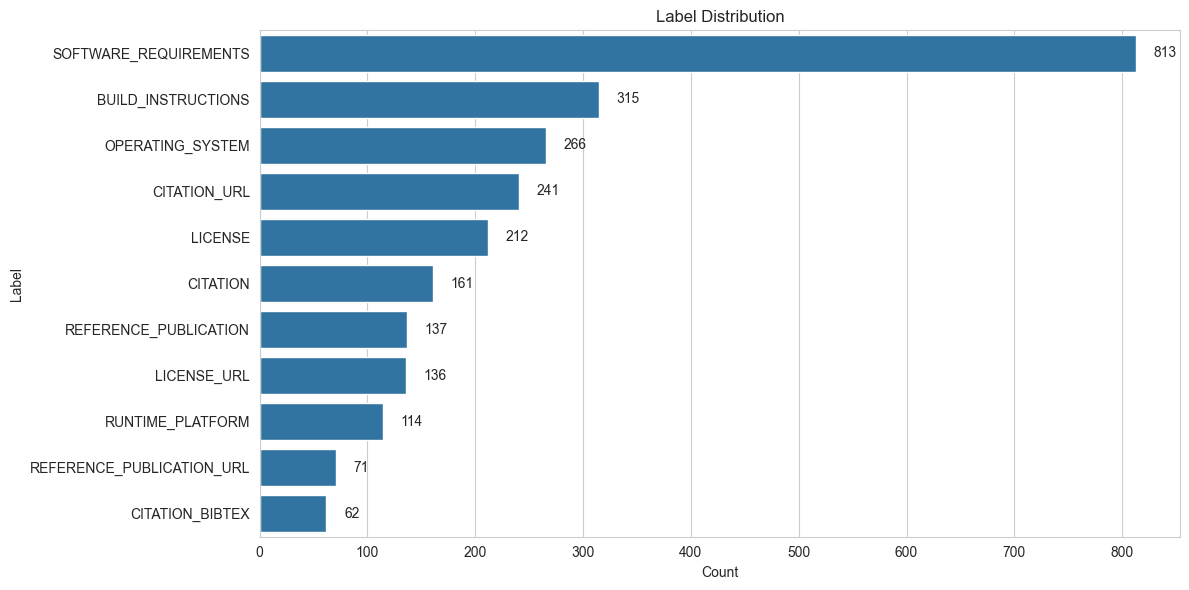

2025-11-12 09:20:25,993 - INFO - Label counts:
                    Label  Count
    SOFTWARE_REQUIREMENTS    813
       BUILD_INSTRUCTIONS    315
         OPERATING_SYSTEM    266
             CITATION_URL    241
                  LICENSE    212
                 CITATION    161
    REFERENCE_PUBLICATION    137
              LICENSE_URL    136
         RUNTIME_PLATFORM    114
REFERENCE_PUBLICATION_URL     71
          CITATION_BIBTEX     62
2025-11-12 09:20:25,993 - INFO - Unique labels: 11
2025-11-12 09:20:25,993 - INFO - Min/Max counts: 62/813 - Imbalance ratio: 13.11


In [12]:
def load_labelstudio_data(file_path: str) -> List[Dict]:
    """Load Label Studio exported JSON dataset."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    logger.info(f"Loaded {len(data)} tasks from {file_path}")
    return data

raw_data = load_labelstudio_data(DATASET_PATH)

# Cell 3: Extract Entities and Analyze Label Distribution
def extract_entities(data: List[Dict]) -> Tuple[List[Dict], Dict[str, int]]:
    """Extract texts and their entities, return list of {'text': str, 'entities': list} and label counts."""
    processed_data = []
    label_counts = Counter()

    for task in data:
        text = task['data']['text']
        entities = []

        if 'annotations' in task and task['annotations']:
            for ann in task['annotations'][0].get('result', []):
                if 'value' in ann:
                    val = ann['value']
                    entities.append({
                        'start': val['start'],
                        'end': val['end'],
                        'label': val['labels'][0],
                        'text': val['text']
                    })
                    label_counts[val['labels'][0]] += 1

        processed_data.append({'text': text, 'entities': entities})

    logger.info(f"Processed {len(processed_data)} documents with {sum(len(d['entities']) for d in processed_data)} entities")
    return processed_data, dict(label_counts)

processed_data, label_counts = extract_entities(raw_data)

# Visualize label distribution with counts on bars
df_labels = pd.DataFrame(list(label_counts.items()), columns=['Label', 'Count']).sort_values('Count', ascending=False)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Count', y='Label', data=df_labels)
plt.title('Label Distribution')

# Add count labels to each bar
for i, (count, label) in enumerate(zip(df_labels['Count'], df_labels['Label'])):
    ax.text(count + 0.02 * max(df_labels['Count']),
            i,
            str(count),
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

logger.info(f"Label counts:\n{df_labels.to_string(index=False)}")
logger.info(f"Unique labels: {len(label_counts)}")
min_count, max_count = df_labels['Count'].min(), df_labels['Count'].max()
logger.info(f"Min/Max counts: {min_count}/{max_count} - Imbalance ratio: {max_count/min_count:.2f}")

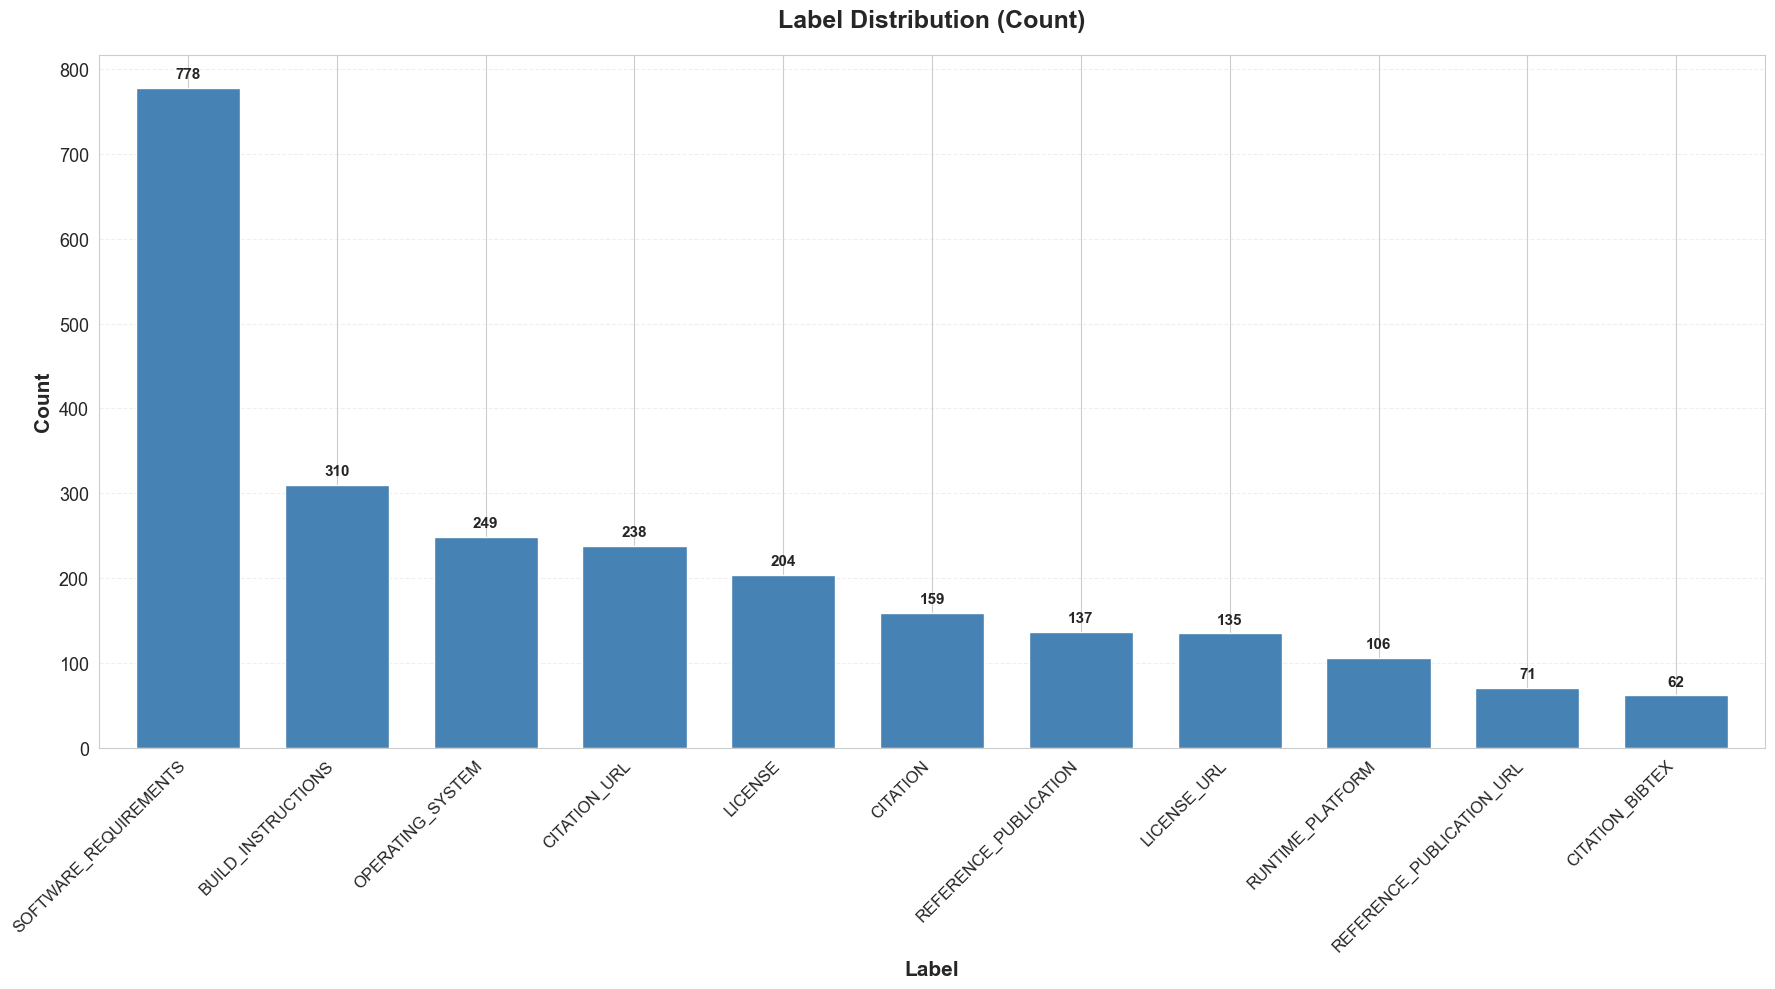

2025-11-10 04:50:16,400 - INFO - Label distribution visualization complete


In [59]:
# Visualize label distribution with improved readability
fig, ax = plt.subplots(figsize=(18, 10))

# Bar plot with better formatting
label_stats['count'].plot(kind='bar', ax=ax, color='steelblue', width=0.7)
ax.set_title('Label Distribution (Count)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Label', fontsize=15, fontweight='bold')
ax.set_ylabel('Count', fontsize=15, fontweight='bold')
ax.set_xticklabels(label_stats.index, rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, v in enumerate(label_stats['count']):
    ax.text(i, v + max(label_stats['count']) * 0.01, str(v), 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

logger.info("Label distribution visualization complete")

## 6. Label Formation Analysis

In [60]:
def analyze_label_formations(df: pd.DataFrame, top_n: int = 10) -> Dict:
    """Analyze the formation/patterns of each label."""
    formations = {}
    
    for label in df['label'].unique():
        label_df = df[df['label'] == label]
        text_counts = label_df['text'].value_counts()
        
        formations[label] = {
            'total_count': len(label_df),
            'unique_values': len(text_counts),
            'top_values': text_counts.head(top_n).to_dict(),
            'avg_length': label_df['length'].mean(),
            'median_length': label_df['length'].median(),
            'min_length': label_df['length'].min(),
            'max_length': label_df['length'].max()
        }
    
    return formations

formations = analyze_label_formations(df_annotations)

# Display formations for each label
for label, stats in formations.items():
    logger.info(f"\n{'='*60}")
    logger.info(f"Label: {label}")
    logger.info(f"Total occurrences: {stats['total_count']}")
    logger.info(f"Unique values: {stats['unique_values']}")
    logger.info(f"Length stats: avg={stats['avg_length']:.1f}, median={stats['median_length']}, min={stats['min_length']}, max={stats['max_length']}")
    logger.info(f"\nTop {len(stats['top_values'])} most common values:")
    for text, count in stats['top_values'].items():
        logger.info(f"  '{text[:50]}...': {count}")

2025-11-10 04:50:16,414 - INFO - 
2025-11-10 04:50:16,414 - INFO - Label: LICENSE
2025-11-10 04:50:16,414 - INFO - Total occurrences: 204
2025-11-10 04:50:16,415 - INFO - Unique values: 106
2025-11-10 04:50:16,415 - INFO - Length stats: avg=19.7, median=17.0, min=3, max=89
2025-11-10 04:50:16,415 - INFO - 
Top 10 most common values:
2025-11-10 04:50:16,416 - INFO -   'GNU General Public License...': 17
2025-11-10 04:50:16,416 - INFO -   'Apache License, Version 2.0...': 13
2025-11-10 04:50:16,416 - INFO -   'MIT license...': 11
2025-11-10 04:50:16,417 - INFO -   'MIT...': 10
2025-11-10 04:50:16,417 - INFO -   'MIT License...': 9
2025-11-10 04:50:16,417 - INFO -   'Apache...': 7
2025-11-10 04:50:16,418 - INFO -   'GNU Affero General Public License...': 5
2025-11-10 04:50:16,418 - INFO -   'Apache License 2.0...': 5
2025-11-10 04:50:16,418 - INFO -   'BSD 3-Clause...': 5
2025-11-10 04:50:16,419 - INFO -   'Apache 2.0...': 4
2025-11-10 04:50:16,419 - INFO - 
2025-11-10 04:50:16,419 - INFO

In [61]:
# Create detailed formation report for each label
def create_formation_report(label: str, df: pd.DataFrame) -> pd.DataFrame:
    """Create a detailed formation report for a specific label."""

    label_df = df[df['label'] == label]
    formation_counts = label_df['text'].value_counts().reset_index()
    formation_counts.columns = ['text', 'count']
    formation_counts['percentage'] = (formation_counts['count'] / len(label_df) * 100).round(2)
    return formation_counts

# Example: Show formation report for LICENSE label
if 'LICENSE' in df_annotations['label'].values:
    license_report = create_formation_report('LICENSE', df_annotations)
    print("\nLICENSE Formation Report:")
    print(license_report.head(50))


LICENSE Formation Report:
                                                 text  count  percentage
0                          GNU General Public License     17        8.33
1                         Apache License, Version 2.0     13        6.37
2                                         MIT license     11        5.39
3                                                 MIT     10        4.90
4                                         MIT License      9        4.41
5                                              Apache      7        3.43
6                   GNU Affero General Public License      5        2.45
7                                  Apache License 2.0      5        2.45
8                                        BSD 3-Clause      5        2.45
9                                          Apache 2.0      4        1.96
10                               BSD 3-Clause License      4        1.96
11                                          CC-BY-4.0      4        1.96
12                      

## 7. Dataset Balance Analysis

In [62]:
def analyze_dataset_balance(df: pd.DataFrame) -> Dict:
    """Analyze dataset balance and identify potential overfitting risks."""
    label_counts = df['label'].value_counts()
    
    # Calculate imbalance metrics
    max_count = label_counts.max()
    min_count = label_counts.min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    # Calculate coefficient of variation
    cv = (label_counts.std() / label_counts.mean()) * 100
    
    balance_info = {
        'max_count': max_count,
        'min_count': min_count,
        'imbalance_ratio': imbalance_ratio,
        'coefficient_of_variation': cv,
        'mean_count': label_counts.mean(),
        'median_count': label_counts.median()
    }
    
    logger.info("\n" + "="*60)
    logger.info("DATASET BALANCE ANALYSIS")
    logger.info("="*60)
    logger.info(f"Maximum label count: {max_count}")
    logger.info(f"Minimum label count: {min_count}")
    logger.info(f"Imbalance ratio: {imbalance_ratio:.2f}")
    logger.info(f"Coefficient of variation: {cv:.2f}%")
    logger.info(f"Mean count per label: {balance_info['mean_count']:.2f}")
    logger.info(f"Median count per label: {balance_info['median_count']:.2f}")
    
    # Provide recommendations
    if imbalance_ratio > 10:
        logger.warning("⚠️  HIGH IMBALANCE DETECTED! Imbalance ratio > 10")
        logger.warning("   Consider data augmentation or resampling techniques")
    elif imbalance_ratio > 5:
        logger.warning("⚠️  MODERATE IMBALANCE DETECTED! Imbalance ratio > 5")
        logger.warning("   Monitor model performance on minority classes")
    else:
        logger.info("✓ Dataset is relatively balanced")
    
    return balance_info

balance_info = analyze_dataset_balance(df_annotations)

2025-11-10 04:50:16,509 - INFO - 
2025-11-10 04:50:16,509 - INFO - DATASET BALANCE ANALYSIS
2025-11-10 04:50:16,510 - INFO - ============================================================
2025-11-10 04:50:16,510 - INFO - Maximum label count: 778
2025-11-10 04:50:16,510 - INFO - Minimum label count: 62
2025-11-10 04:50:16,510 - INFO - Imbalance ratio: 12.55
2025-11-10 04:50:16,511 - INFO - Coefficient of variation: 89.70%
2025-11-10 04:50:16,511 - INFO - Mean count per label: 222.64
2025-11-10 04:50:16,511 - INFO - Median count per label: 159.00
2025-11-10 04:50:16,511 - WARNING - ⚠️  HIGH IMBALANCE DETECTED! Imbalance ratio > 10
2025-11-10 04:50:16,512 - WARNING -    Consider data augmentation or resampling techniques


## 8. Overfitting Risk Analysis

In [63]:
def analyze_overfitting_risk(df: pd.DataFrame) -> pd.DataFrame:
    """Identify potential overfitting risks based on repetition patterns."""
    overfitting_risks = []
    
    for label in df['label'].unique():
        label_df = df[df['label'] == label]
        text_counts = label_df['text'].value_counts()
        
        # Calculate diversity metrics
        total_count = len(label_df)
        unique_count = len(text_counts)
        diversity_ratio = unique_count / total_count if total_count > 0 else 0
        
        # Find highly repeated values
        high_repetition = text_counts[text_counts > (total_count * 0.1)]  # >10% repetition
        
        risk_level = 'LOW'
        if diversity_ratio < 0.3:
            risk_level = 'HIGH'
        elif diversity_ratio < 0.6:
            risk_level = 'MEDIUM'
        
        overfitting_risks.append({
            'label': label,
            'total_count': total_count,
            'unique_count': unique_count,
            'diversity_ratio': diversity_ratio,
            'high_repetition_count': len(high_repetition),
            'risk_level': risk_level
        })
    
    risk_df = pd.DataFrame(overfitting_risks).sort_values('diversity_ratio')
    
    logger.info("\n" + "="*60)
    logger.info("OVERFITTING RISK ANALYSIS")
    logger.info("="*60)
    
    for _, row in risk_df.iterrows():
        logger.info(f"\nLabel: {row['label']}")
        logger.info(f"  Diversity ratio: {row['diversity_ratio']:.2%}")
        logger.info(f"  Risk level: {row['risk_level']}")
        logger.info(f"  Highly repeated values: {row['high_repetition_count']}")
    
    return risk_df

risk_analysis = analyze_overfitting_risk(df_annotations)
risk_analysis

2025-11-10 04:50:16,525 - INFO - 
2025-11-10 04:50:16,525 - INFO - OVERFITTING RISK ANALYSIS
2025-11-10 04:50:16,525 - INFO - ============================================================
2025-11-10 04:50:16,526 - INFO - 
Label: OPERATING_SYSTEM
2025-11-10 04:50:16,526 - INFO -   Diversity ratio: 14.46%
2025-11-10 04:50:16,526 - INFO -   Risk level: HIGH
2025-11-10 04:50:16,527 - INFO -   Highly repeated values: 2
2025-11-10 04:50:16,527 - INFO - 
Label: LICENSE
2025-11-10 04:50:16,527 - INFO -   Diversity ratio: 51.96%
2025-11-10 04:50:16,527 - INFO -   Risk level: MEDIUM
2025-11-10 04:50:16,528 - INFO -   Highly repeated values: 0
2025-11-10 04:50:16,528 - INFO - 
Label: SOFTWARE_REQUIREMENTS
2025-11-10 04:50:16,528 - INFO -   Diversity ratio: 67.74%
2025-11-10 04:50:16,529 - INFO -   Risk level: LOW
2025-11-10 04:50:16,529 - INFO -   Highly repeated values: 0
2025-11-10 04:50:16,529 - INFO - 
Label: LICENSE_URL
2025-11-10 04:50:16,530 - INFO -   Diversity ratio: 74.07%
2025-11-10 04:

,label,total_count,unique_count,diversity_ratio,high_repetition_count,risk_level
6,OPERATING_SYSTEM,249,36,0.144578,2,HIGH
0,LICENSE,204,106,0.519608,0,MEDIUM
1,SOFTWARE_REQUIREMENTS,778,527,0.677378,0,LOW
9,LICENSE_URL,135,100,0.740741,0,LOW
2,RUNTIME_PLATFORM,106,81,0.764151,0,LOW
5,REFERENCE_PUBLICATION_URL,71,64,0.901408,0,LOW
3,BUILD_INSTRUCTIONS,310,283,0.912903,0,LOW
8,CITATION_URL,238,222,0.932773,0,LOW
4,REFERENCE_PUBLICATION,137,136,0.992701,0,LOW
7,CITATION,159,158,0.993711,0,LOW


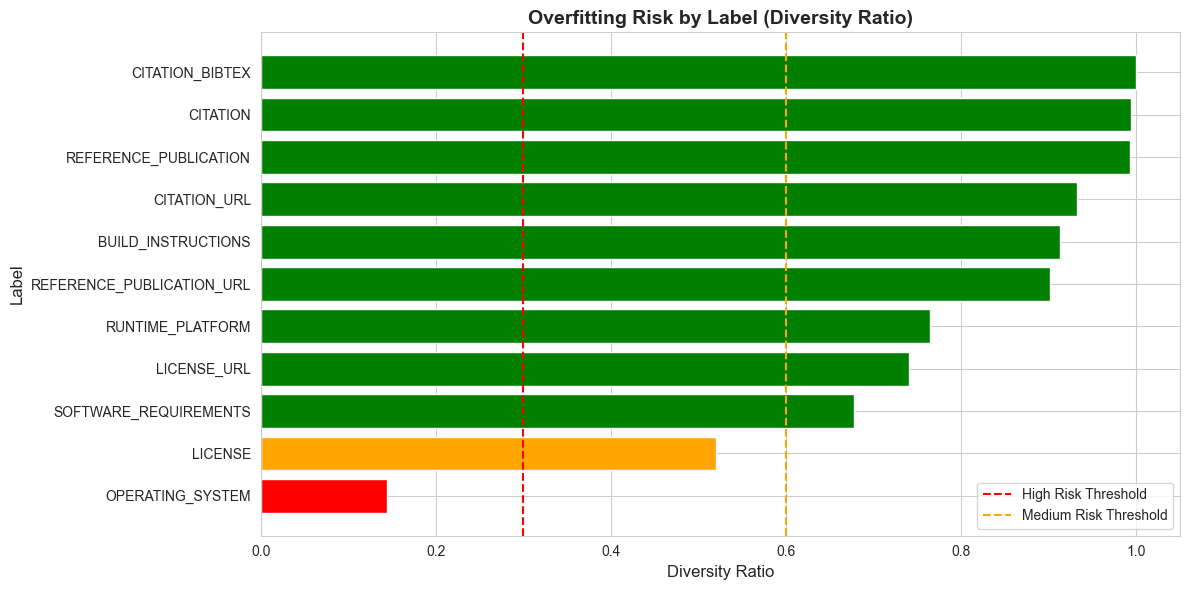

In [64]:
# Visualize overfitting risk
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'}
bar_colors = [colors[risk] for risk in risk_analysis['risk_level']]

ax.barh(risk_analysis['label'], risk_analysis['diversity_ratio'], color=bar_colors)
ax.set_xlabel('Diversity Ratio', fontsize=12)
ax.set_ylabel('Label', fontsize=12)
ax.set_title('Overfitting Risk by Label (Diversity Ratio)', fontsize=14, fontweight='bold')
ax.axvline(x=0.3, color='red', linestyle='--', label='High Risk Threshold')
ax.axvline(x=0.6, color='orange', linestyle='--', label='Medium Risk Threshold')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Label Deletion Tool

In [65]:
def delete_label_from_dataset(dataset: List[Dict], label_to_delete: str) -> List[Dict]:
    """Remove all annotations of a specific label from the dataset."""
    deleted_count = 0
    
    for sample in dataset:
        for annotation in sample.get('annotations', []):
            original_count = len(annotation.get('result', []))
            
            # Filter out the label
            annotation['result'] = [
                result for result in annotation.get('result', [])
                if not (result.get('type') == 'labels' and 
                       label_to_delete in result.get('value', {}).get('labels', []))
            ]
            
            deleted_count += original_count - len(annotation['result'])
            annotation['result_count'] = len(annotation['result'])
    
    logger.info(f"Deleted {deleted_count} annotations with label '{label_to_delete}'")
    return dataset

def save_cleaned_dataset(dataset: List[Dict], output_path: Path):
    """Save the cleaned dataset to a file."""
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(dataset, f, indent=2, ensure_ascii=False)
    logger.info(f"Saved cleaned dataset to {output_path}")

# Example usage (commented out to prevent accidental deletion)
#label_to_remove = 'REFERENCE_PUBLICATION_BIBTEX'
#cleaned_dataset = delete_label_from_dataset(dataset.copy(), label_to_remove)
#save_cleaned_dataset(cleaned_dataset, DATASET_PATH.parent / 'o_dataset.json')

## 10. Interactive Label Deletion

In [66]:
# Interactive deletion cell
print("Available labels:")
for i, label in enumerate(df_annotations['label'].unique(), 1):
    count = len(df_annotations[df_annotations['label'] == label])
    print(f"{i}. {label} ({count} annotations)")

print("\nTo delete a label, uncomment and modify the following code:")
print("# LABEL_TO_DELETE = 'YOUR_LABEL_HERE'")
print("# cleaned_dataset = delete_label_from_dataset(dataset.copy(), LABEL_TO_DELETE)")
print("# save_cleaned_dataset(cleaned_dataset, DATASET_PATH.parent / 'dataset_cleaned.json')")

Available labels:
1. LICENSE (204 annotations)
2. SOFTWARE_REQUIREMENTS (778 annotations)
3. RUNTIME_PLATFORM (106 annotations)
4. BUILD_INSTRUCTIONS (310 annotations)
5. REFERENCE_PUBLICATION (137 annotations)
6. REFERENCE_PUBLICATION_URL (71 annotations)
7. OPERATING_SYSTEM (249 annotations)
8. CITATION (159 annotations)
9. CITATION_URL (238 annotations)
10. LICENSE_URL (135 annotations)
11. CITATION_BIBTEX (62 annotations)

To delete a label, uncomment and modify the following code:
# LABEL_TO_DELETE = 'YOUR_LABEL_HERE'
# cleaned_dataset = delete_label_from_dataset(dataset.copy(), LABEL_TO_DELETE)
# save_cleaned_dataset(cleaned_dataset, DATASET_PATH.parent / 'dataset_cleaned.json')


## 11. Summary Report

In [67]:
def generate_summary_report(df: pd.DataFrame, balance_info: Dict, risk_analysis: pd.DataFrame):
    """Generate a comprehensive summary report."""
    logger.info("\n" + "="*60)
    logger.info("DATASET SUMMARY REPORT")
    logger.info("="*60)
    
    logger.info(f"\nTotal annotations: {len(df)}")
    logger.info(f"Total unique labels: {df['label'].nunique()}")
    logger.info(f"Total samples: {df['sample_id'].nunique()}")
    
    logger.info(f"\nBalance Metrics:")
    logger.info(f"  Imbalance ratio: {balance_info['imbalance_ratio']:.2f}")
    logger.info(f"  Coefficient of variation: {balance_info['coefficient_of_variation']:.2f}%")
    
    high_risk_labels = risk_analysis[risk_analysis['risk_level'] == 'HIGH']
    logger.info(f"\nOverfitting Risk:")
    logger.info(f"  High risk labels: {len(high_risk_labels)}")
    if len(high_risk_labels) > 0:
        logger.info(f"  Labels: {', '.join(high_risk_labels['label'].tolist())}")
    
    logger.info("\nRecommendations:")
    if balance_info['imbalance_ratio'] > 5:
        logger.info("  - Consider data augmentation for minority classes")
        logger.info("  - Use class weights during training")
    if len(high_risk_labels) > 0:
        logger.info("  - Collect more diverse examples for high-risk labels")
        logger.info("  - Consider data augmentation techniques")
    
    logger.info("\n" + "="*60)

generate_summary_report(df_annotations, balance_info, risk_analysis)

2025-11-10 04:50:16,662 - INFO - 
2025-11-10 04:50:16,663 - INFO - DATASET SUMMARY REPORT
2025-11-10 04:50:16,663 - INFO - ============================================================
2025-11-10 04:50:16,664 - INFO - 
Total annotations: 2449
2025-11-10 04:50:16,664 - INFO - Total unique labels: 11
2025-11-10 04:50:16,665 - INFO - Total samples: 807
2025-11-10 04:50:16,665 - INFO - 
Balance Metrics:
2025-11-10 04:50:16,665 - INFO -   Imbalance ratio: 12.55
2025-11-10 04:50:16,666 - INFO -   Coefficient of variation: 89.70%
2025-11-10 04:50:16,667 - INFO - 
Overfitting Risk:
2025-11-10 04:50:16,667 - INFO -   High risk labels: 1
2025-11-10 04:50:16,668 - INFO -   Labels: OPERATING_SYSTEM
2025-11-10 04:50:16,668 - INFO - 
Recommendations:
2025-11-10 04:50:16,668 - INFO -   - Consider data augmentation for minority classes
2025-11-10 04:50:16,669 - INFO -   - Use class weights during training
2025-11-10 04:50:16,669 - INFO -   - Collect more diverse examples for high-risk labels
2025-11-10

## 12. Export Analysis Results

In [68]:
# Export analysis results to CSV
output_dir = Path('../data/analysis_results')
output_dir.mkdir(exist_ok=True, parents=True)

# Export label statistics
label_stats.to_csv(output_dir / 'label_statistics.csv')
logger.info(f"Exported label statistics to {output_dir / 'label_statistics.csv'}")

# Export risk analysis
risk_analysis.to_csv(output_dir / 'overfitting_risk_analysis.csv', index=False)
logger.info(f"Exported risk analysis to {output_dir / 'overfitting_risk_analysis.csv'}")

# Export formation reports for each label
for label in df_annotations['label'].unique():
    formation_report = create_formation_report(label, df_annotations)
    safe_label = label.replace('/', '_').replace(' ', '_')
    formation_report.to_csv(output_dir / f'formation_{safe_label}.csv', index=False)

logger.info(f"Exported all formation reports to {output_dir}")
logger.info("\nAnalysis complete!")

2025-11-10 04:50:16,677 - INFO - Exported label statistics to ../data/analysis_results/label_statistics.csv
2025-11-10 04:50:16,680 - INFO - Exported risk analysis to ../data/analysis_results/overfitting_risk_analysis.csv
2025-11-10 04:50:16,695 - INFO - Exported all formation reports to ../data/analysis_results
2025-11-10 04:50:16,695 - INFO - 
Analysis complete!
